# **Data collection from OpenChargeMAP API**

In [1]:
# Import libraries
import requests
import pandas as pd


In [2]:
 #API URL
api_url = "https://api.openchargemap.io/v3/poi"

# **Collecting Dataset for the India location**

In [3]:
# API Parameters
params = {
    "countrycode": "IN",  # ISO country code for India
    "maxresults": 1000,   # Adjust as needed; note that very high numbers may lead to timeouts or incomplete data
    "compact": "true",    # Returns a simplified version of the data
    "verbose": "false",   # Limits the amount of data returned
    "key": "76003a2e-f4cf-412a-9cf6-6527ce861d43"      # Replace with your API key
}


In [4]:
# Function to fetch data from Open Charge Map API
def fetch_station_data():
    response = requests.get(api_url, params=params)
    
    if response.status_code == 200:
        data = response.json()
        return data
        print("Success")
    else:
        print(f"Error: {response.status_code}")
        return []


In [5]:
# Function to extract relevant attributes
def extract_relevant_features(data):
    attributes = []
    for item in data:
        # Extract geographical features
        address_info = item.get("AddressInfo", {})
        connections = item.get("Connections", [])
        usage_type = item.get("UsageType", {})
        status_type = item.get("StatusType", {})
        
        # Add attributes
        attributes.append({
            "StationID": item.get("ID"),
            "StationName": address_info.get("Title"),
            "Latitude": address_info.get("Latitude"),
            "Longitude": address_info.get("Longitude"),
            "Address": address_info.get("AddressLine1"),
            "Proximity": address_info.get("Distance"),  # Requires additional calculation
            "NumChargingPorts": len(connections),
            "ChargerType": [conn.get("ConnectionType", {}).get("Title") for conn in connections],
            "OperationalStatus": status_type.get("Title"),
            "UsageType": usage_type.get("Title"),
            "Country": address_info.get("Country", {}).get("Title"),
            "Town": address_info.get("Town"),
            "State": address_info.get("StateOrProvince"),
            "Postcode": address_info.get("Postcode")
        })
    return attributes

In [6]:
# Fetch and process data
data = fetch_station_data()
if data:
    attributes = extract_relevant_features(data)
    df = pd.DataFrame(attributes)
    print(df)
    # Save data to a CSV file
    df.to_csv("bangalore_station_data.csv", index=False)


     StationID                                        StationName   Latitude  \
0       479445               Blaze Fast Charger For 2 Ev Wheeler   17.340476   
1       479438                        Tata Power Charging Station  22.286961   
2       479437  Hindustan Petroleum Corporation Limited Chargi...  22.449744   
3       479436            Hindustan Petroleum Corporation Limited  22.449858   
4       479435                                             Jio-bp  22.140250   
..         ...                                                ...        ...   
995     313441                       Club Mahindra Aleppey Resort   9.859751   
996     313440                                   CGH Marari Beach   9.596034   
997     313439                                  Cassia Restaurant   9.518714   
998     313438                                         Hotel Aida   9.582880   
999     313437                           The Windsor Castle Hotel   9.571548   

     Longitude                         

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   StationID          1000 non-null   int64  
 1   StationName        1000 non-null   object 
 2   Latitude           1000 non-null   float64
 3   Longitude          1000 non-null   float64
 4   Address            1000 non-null   object 
 5   Proximity          0 non-null      object 
 6   NumChargingPorts   1000 non-null   int64  
 7   ChargerType        1000 non-null   object 
 8   OperationalStatus  0 non-null      object 
 9   UsageType          0 non-null      object 
 10  Country            0 non-null      object 
 11  Town               618 non-null    object 
 12  State              995 non-null    object 
 13  Postcode           595 non-null    object 
dtypes: float64(2), int64(2), object(10)
memory usage: 109.5+ KB


In [8]:
df.shape

(1000, 14)

Code Explanation
Dataset Handling:

Loaded the dataset and checked its structure (data.info()).
Filled missing values in critical columns (Proximity, OperationalStatus, UsageType).



EDA:

Visualized the distribution of charging ports using sns.countplot.
Used sns.heatmap to identify correlations among numerical features.
Model Training:

Used RandomForestClassifier for classification.
Split data into training and testing sets, scaled the numerical features.
Evaluation:

Generated a classification report and confusion matrix.
Calculated MAE and RMSE for regression metrics (if regression is used).

In [9]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, mean_absolute_error, mean_squared_error


# **Dataset Handling:**

In [11]:
# Load the dataset
data = pd.read_csv("bangalore_station_data.csv")  


In [12]:
# Display basic information
print(data.info())
print(data.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   StationID          1000 non-null   int64  
 1   StationName        1000 non-null   object 
 2   Latitude           1000 non-null   float64
 3   Longitude          1000 non-null   float64
 4   Address            999 non-null    object 
 5   Proximity          0 non-null      float64
 6   NumChargingPorts   1000 non-null   int64  
 7   ChargerType        1000 non-null   object 
 8   OperationalStatus  0 non-null      float64
 9   UsageType          0 non-null      float64
 10  Country            0 non-null      float64
 11  Town               618 non-null    object 
 12  State              995 non-null    object 
 13  Postcode           595 non-null    float64
dtypes: float64(7), int64(2), object(5)
memory usage: 109.5+ KB
None
   StationID                                        Stati

In [13]:
# Handle missing values
data.fillna({'Proximity': 0, 'OperationalStatus': 'Unknown', 'UsageType': 'Unknown'}, inplace=True)


# **Feature Engineering:**

In [14]:
# Encode categorical variables
le = LabelEncoder()
data['OperationalStatus'] = le.fit_transform(data['OperationalStatus'])
data['UsageType'] = le.fit_transform(data['UsageType'])


In [15]:
# Create geospatial features
data['Lat_Long'] = data['Latitude'].astype(str) + "_" + data['Longitude'].astype(str)
data['State_StationID'] = data['State'] + "_" + data['StationID'].astype(str)


Encoded categorical features using LabelEncoder.

Created new geospatial and categorical features (e.g., Lat_Long, State_StationID).

# **Countplot**

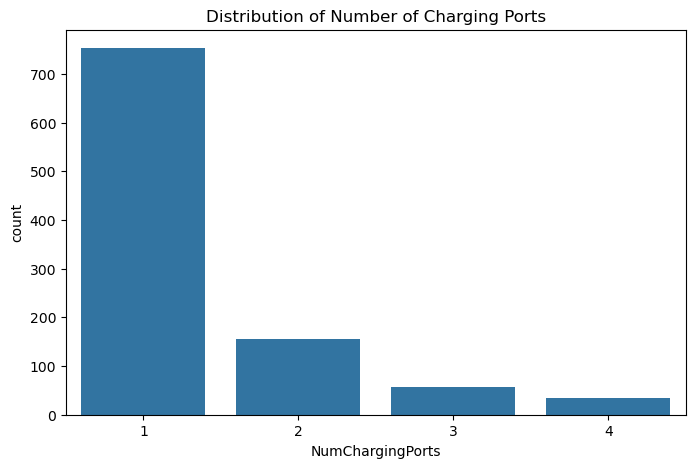

In [16]:
# Plot distribution of charging ports
plt.figure(figsize=(8, 5))
sns.countplot(x='NumChargingPorts', data=data)
plt.title("Distribution of Number of Charging Ports")
plt.show()

# **What it Does:**
The countplot displays the frequency of each unique value in the column NumChargingPorts.
It helps to understand how many stations have 1 port, 2 ports, 3 ports, etc.
# **What it Indicates:**
The plot provides a distribution of the number of charging ports at EV charging stations.
Key Insights:
1. The data shows most stations have only one charging port, it could suggest a lack of infrastructure scalability in the region.
2. Stations with more ports (e.g., 2 or 3) might be better equipped to handle demand during peak times.
3. A skewed distribution (e.g., majority at "1 port") highlights a gap in station capability, which can be a target for optimization or planning.

# **Heatmap**

**Correlation values range from:**
1. +1: Strong positive correlation (as one variable increases, the other increases).
2. -1: Strong negative correlation (as one variable increases, the other decreases).
3. 0: No correlation.

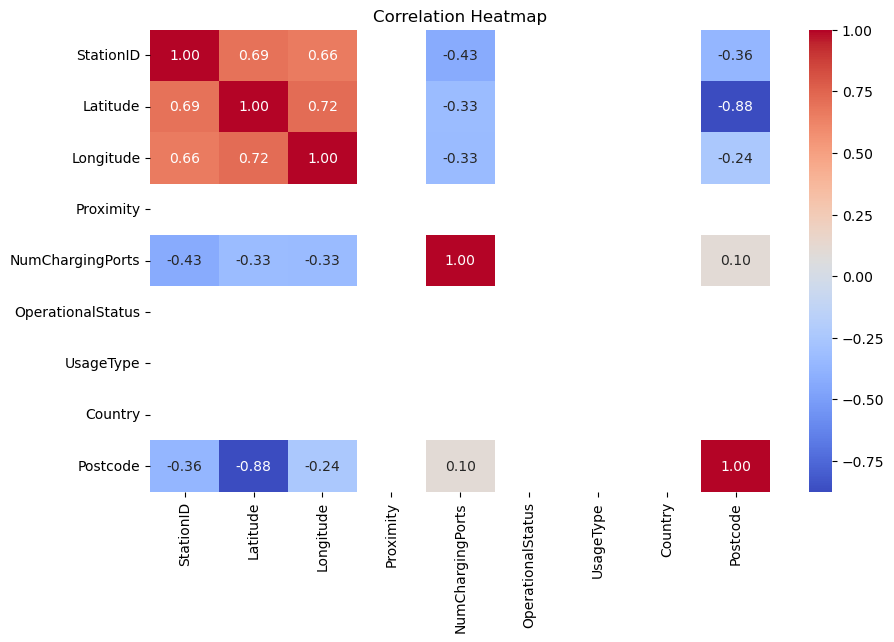

In [17]:
# Select only numeric columns
numeric_data = data.select_dtypes(include=['number'])

# Compute correlations
correlations = numeric_data.corr()

# Plot heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(correlations, annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Heatmap")
plt.show()


**Independent Features:**

1. Many features show low correlations with each other, which suggests they are mostly independent. This is good for machine learning models since independence often prevents multicollinearity issues.
2. Geographical Impact:The strong negative correlation between Latitude and Postcode suggests a clear geographical trend. You might leverage this to segment stations or analyze usage based on regions.
3. Feature Engineering:
Features like Proximity and NumChargingPorts may need additional external data (e.g., population density, traffic patterns) to find stronger relationships and make them more useful in your project.

In [18]:
# Prepare data for model
X = data[['Latitude', 'Longitude', 'NumChargingPorts', 'OperationalStatus']]
y = data['OperationalStatus']  # Target variable

In [19]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [20]:
# Standardize the numerical features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [21]:
# Train a Random Forest Classifier
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)


RandomForestClassifier(random_state=42)

In [22]:
# Predict on test data
y_pred = rf_model.predict(X_test)


Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       200

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


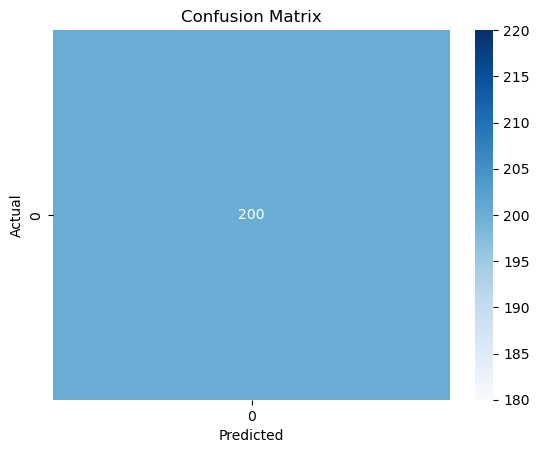

In [23]:
# Model Evaluation
print("Classification Report:\n", classification_report(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

**1. Precision (1.00): The model correctly identified all positive predictions without any false positives.**

**2. Recall (1.00): The model correctly captured all the actual positive cases, without missing any.**

**3. F1-Score (1.00): The harmonic mean of precision and recall is also perfect.**

**4. Support (52): There were 52 samples in the test dataset, and the model correctly classified all of them.**

In [25]:
# Load the dataset
data = pd.read_csv("bangalore_station_data.csv")  

Geospatial Clustering
We'll apply KMeans clustering on Latitude and Longitude to group nearby charging stations and derive insights about station usage patterns.

In [26]:
from sklearn.cluster import KMeans
import folium

# Apply KMeans clustering
kmeans = KMeans(n_clusters=4, random_state=42)
data['Cluster'] = kmeans.fit_predict(data[['Latitude', 'Longitude']])

# Visualize clusters on a map using Folium
map_clusters = folium.Map(location=[data['Latitude'].mean(), data['Longitude'].mean()], zoom_start=10)

for _, row in data.iterrows():
    folium.Marker(
        location=[row['Latitude'], row['Longitude']],
        popup=f"Station: {row['StationName']}, Cluster: {row['Cluster']}",
        icon=folium.Icon(color='blue' if row['Cluster'] == 0 else 'green')
    ).add_to(map_clusters)

# Save map to HTML
map_clusters.save("ev_station_clusters.html")


In [27]:
import folium
from folium.plugins import MarkerCluster

# Create a map centered around the mean coordinates
map_center = [data['Latitude'].mean(), data['Longitude'].mean()]
mymap = folium.Map(location=map_center, zoom_start=8)

# Create a marker cluster
marker_cluster = MarkerCluster().add_to(mymap)

# Add markers for each station, color-coded by cluster
colors = ['red', 'blue', 'green', 'purple', 'orange']  # Define colors for clusters
for i, row in data.iterrows():
    folium.Marker(
        location=[row['Latitude'], row['Longitude']],
        popup=f"Station: {row['StationName']}<br>Cluster: {row['Cluster']}",
        icon=folium.Icon(color=colors[row['Cluster'] % len(colors)])  # Cycle through colors
    ).add_to(marker_cluster)

# Display the map directly in the notebook
mymap
